In [5]:
import pandas as pd

The file data/apple_history.csv was actually retrieved from an online API. The code used is shown below, but it may be blocked, in which case you should use the CSV file.

In [6]:
# import yfinance
# apple = yfinance.Ticker("AAPL")
# apple_df = apple.history(period="1d", start="2010-01-01", end="2025-01-01")
# print(apple_df.head())

In [7]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("../../../data")

apple_df = pd.read_csv(DATA_DIR / "apple_history.csv")

Explore this file. Are there any missing values?

In [8]:
apple_df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-01-04 00:00:00-05:00,6.414463,6.446621,6.382907,6.431895,493729600,0.0,0.0
1,2010-01-05 00:00:00-05:00,6.449629,6.479382,6.409055,6.443017,601904800,0.0,0.0
2,2010-01-06 00:00:00-05:00,6.443018,6.468564,6.333921,6.340533,552160000,0.0,0.0
3,2010-01-07 00:00:00-05:00,6.363974,6.371488,6.282828,6.328811,477131200,0.0,0.0
4,2010-01-08 00:00:00-05:00,6.320397,6.371489,6.283130,6.370888,447610800,0.0,0.0


In [9]:
apple_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          3774 non-null   object 
 1   Open          3774 non-null   float64
 2   High          3774 non-null   float64
 3   Low           3774 non-null   float64
 4   Close         3774 non-null   float64
 5   Volume        3774 non-null   int64  
 6   Dividends     3774 non-null   float64
 7   Stock Splits  3774 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 236.0+ KB


In [10]:
apple_df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,3774.000000,3774.000000,3774.000000,3774.000000,3.774000e+03,3774.000000,3774.000000
mean,67.377155,68.086942,66.709768,67.433262,2.299200e+08,0.002316,0.002915
std,65.438023,66.125667,64.819099,65.516757,2.180726e+08,0.020785,0.131222
min,5.781524,5.890620,5.717810,5.771908,2.323470e+07,0.000000,0.000000
25%,17.442398,17.622328,17.293327,17.438814,8.492275e+07,0.000000,0.000000
50%,35.308430,35.681947,34.917551,35.277456,1.403920e+08,0.000000,0.000000
75%,126.173636,127.831540,124.664336,126.743427,3.081386e+08,0.000000,0.000000
max,257.568678,259.474086,257.010028,258.396667,1.880998e+09,0.250000,7.000000


There are no missing values.

Visualize the history of closing prices using a simple plot.

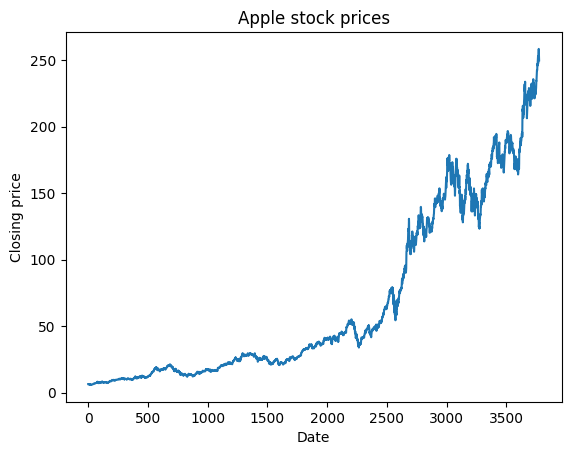

In [11]:
import matplotlib.pyplot as plt

plt.plot(apple_df.index, apple_df["Close"])
plt.title("Apple stock prices")
plt.xlabel("Date")
plt.ylabel("Closing price")
plt.show()

Compute the relative change in the closing price from one day to the next. To do this, look in the documentation or online for a pandas Series method that directly performs this calculation.

In [12]:
apple_df["relative_variation"] = apple_df["Close"].pct_change().fillna(0)

In [13]:
apple_df

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,relative_variation
0,2010-01-04 00:00:00-05:00,6.414463,6.446621,6.382907,6.431895,493729600,0.0,0.0,0.000000
1,2010-01-05 00:00:00-05:00,6.449629,6.479382,6.409055,6.443017,601904800,0.0,0.0,0.001729
2,2010-01-06 00:00:00-05:00,6.443018,6.468564,6.333921,6.340533,552160000,0.0,0.0,-0.015906
3,2010-01-07 00:00:00-05:00,6.363974,6.371488,6.282828,6.328811,477131200,0.0,0.0,-0.001849
4,2010-01-08 00:00:00-05:00,6.320397,6.371489,6.283130,6.370888,447610800,0.0,0.0,0.006648
...,...,...,...,...,...,...,...,...,...
3769,2024-12-24 00:00:00-05:00,254.875189,257.588630,254.675658,257.578674,23234700,0.0,0.0,0.011478
3770,2024-12-26 00:00:00-05:00,257.568678,259.474086,257.010028,258.396667,27237100,0.0,0.0,0.003176
3771,2024-12-27 00:00:00-05:00,257.209530,258.077462,252.451019,254.974930,42355300,0.0,0.0,-0.013242
3772,2024-12-30 00:00:00-05:00,251.623005,252.889953,250.146571,251.593079,35557500,0.0,0.0,-0.013263


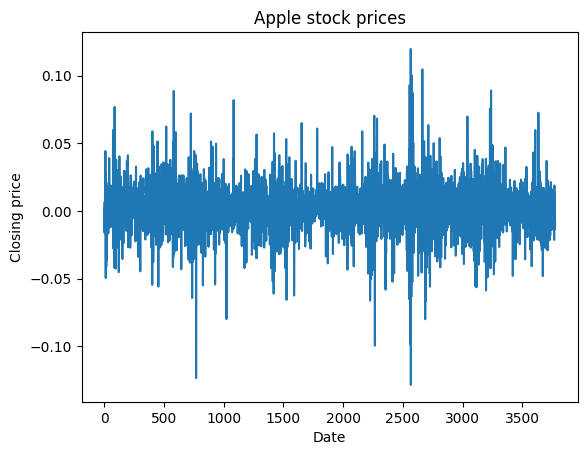

In [14]:
plt.plot(apple_df.index, apple_df["relative_variation"])
plt.title("Apple stock prices")
plt.xlabel("Date")
plt.ylabel("Closing price")
plt.show()

Compute the relative change in the closing price from one day to the next. To do this, look in the documentation or online for a pandas Series method that directly performs this calculation.

In [15]:
from scipy.stats import zscore

apple_df["z_score"] = zscore(
    apple_df["relative_variation"],
    # nan_policy="omit",
)

In [16]:
unusual_data = apple_df[abs(apple_df["z_score"]) > 5]
len(unusual_data)

9

In [17]:
unusual_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,relative_variation,z_score
769,2013-01-24 00:00:00-05:00,13.947698,14.121438,13.652066,13.659648,1460852400,0.0,0.0,-0.123558,-7.105464
2265,2019-01-03 00:00:00-05:00,34.297218,34.711701,33.825567,33.870827,365248800,0.0,0.0,-0.099608,-5.740562
2556,2020-03-02 00:00:00-05:00,68.413722,73.057364,67.308555,72.419952,341397200,0.0,0.0,0.093101,5.241603
2564,2020-03-12 00:00:00-04:00,62.029918,65.437516,60.105570,60.161312,418474000,0.0,0.0,-0.098755,-5.691963
2565,2020-03-13 00:00:00-04:00,64.199052,67.841740,61.305256,67.369133,370732000,0.0,0.0,0.119808,6.763638


Visualize the associated rows, as well as the rows from the preceding days.

In [18]:
outlier_mask = abs(apple_df["z_score"]) > 5
display_mask = outlier_mask | outlier_mask.shift(-1, fill_value=False)
apple_df[display_mask]

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,relative_variation,z_score
768,2013-01-23 00:00:00-05:00,15.427672,15.615057,15.305176,15.585342,861509600,0.0,0.0,0.018305,0.979121
769,2013-01-24 00:00:00-05:00,13.947698,14.121438,13.652066,13.659648,1460852400,0.0,0.0,-0.123558,-7.105464
2264,2019-01-02 00:00:00-05:00,36.896080,37.839387,36.738862,37.617851,148158800,0.0,0.0,0.001141,0.000972
2265,2019-01-03 00:00:00-05:00,34.297218,34.711701,33.825567,33.870827,365248800,0.0,0.0,-0.099608,-5.740562
2555,2020-02-28 00:00:00-05:00,62.349859,67.475798,62.134154,66.251869,426510000,0.0,0.0,-0.000585,-0.097390
2556,2020-03-02 00:00:00-05:00,68.413722,73.057364,67.308555,72.419952,341397200,0.0,0.0,0.093101,5.241603
2563,2020-03-11 00:00:00-04:00,67.228581,68.156821,65.888316,66.753548,255598800,0.0,0.0,-0.034730,-2.043296
2564,2020-03-12 00:00:00-04:00,62.029918,65.437516,60.105570,60.161312,418474000,0.0,0.0,-0.098755,-5.691963
2565,2020-03-13 00:00:00-04:00,64.199052,67.841740,61.305256,67.369133,370732000,0.0,0.0,0.119808,6.763638
2566,2020-03-16 00:00:00-04:00,58.639296,62.790941,58.166693,58.702312,322423600,0.0,0.0,-0.128647,-7.395462


Compute the quartiles Q1 and Q3, the interquartile range (IQR), and identify points outside the range [Q1 − 1.5 × IQR; Q3 + 1.5 × IQR]. Visualize the associated rows, as well as the rows from the preceding days.

In [19]:
q1  = apple_df["relative_variation"].quantile(0.25)
q3  = apple_df["relative_variation"].quantile(0.75)
iqr = q3 - q1

borne_inf = q1 - 1.5 * iqr
borne_sup = q3 + 1.5 * iqr

apple_df["outlier_iqr"] = (apple_df["relative_variation"] < borne_inf) | (apple_df["relative_variation"] > borne_sup)

outliers_iqr = apple_df[apple_df["outlier_iqr"]]

In [20]:
outlier_mask = apple_df["outlier_iqr"]
mask_pairs = outlier_mask | outlier_mask.shift(-1, fill_value=False)
apple_df[mask_pairs].head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,relative_variation,z_score,outlier_iqr
9,2010-01-15 00:00:00-05:00,6.339331,6.359467,6.187256,6.189060,594067600,0.0,0.0,-0.016712,-1.016456,False
10,2010-01-19 00:00:00-05:00,6.261189,6.467360,6.228430,6.462852,730007600,0.0,0.0,0.044238,2.457003,True
12,2010-01-21 00:00:00-05:00,6.373891,6.410857,6.227527,6.253373,608154400,0.0,0.0,-0.017286,-1.049195,False
13,2010-01-22 00:00:00-05:00,6.214605,6.236244,5.925484,5.943215,881767600,0.0,0.0,-0.049598,-2.890612,True
16,2010-01-27 00:00:00-05:00,6.216709,6.328811,5.996712,6.247665,1722568400,0.0,0.0,0.009420,0.472786,False


So far, we have only used a single column (the closing price). Visualize the correlation matrix of the dataframe columns.

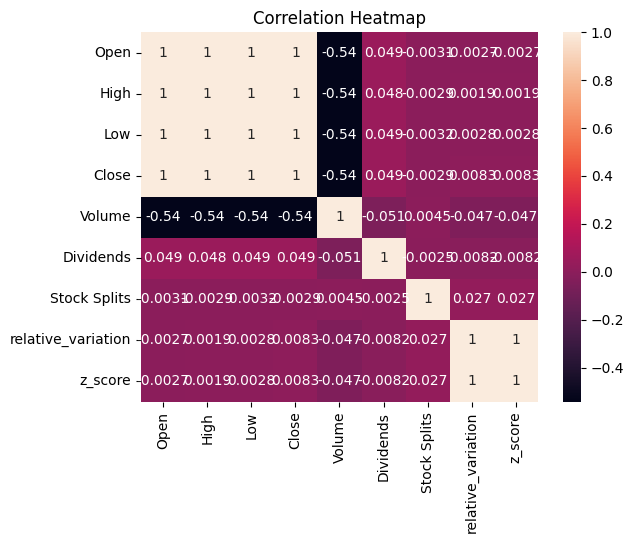

In [21]:
import seaborn as sns
import numpy as np

num_cols = apple_df.select_dtypes(include=np.number)

correlation_matrix = num_cols.corr()
sns.heatmap(correlation_matrix, annot=True)
plt.title("Correlation Heatmap")
plt.show()

Let us use some of these columns to build a simple prediction model. Try to perform a linear regression of the closing price using columns you consider relevant.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = apple_df.drop(columns=["Close", "Date"])
y = apple_df["Close"]

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Display the model coefficients
model.coef_

array([-4.59000330e-01,  7.29242258e-01,  7.30316490e-01,  1.11279947e-10,
        5.31621198e-01, -2.34753704e-02,  3.85397903e-03,  2.19632837e-01,
       -1.60407410e-01])

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions on the test data
y_pred = model.predict(X_test)

# Compute evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 0.31667198492070825
R-squared: 0.9999253015377029


Is it possible to predict today's closing price? Criticize the use of linear regression for this application.

Bonus: if you have time left, try to fit an ARIMA model to the closing price.

In [25]:
import statsmodels.api as sm

close_pd = (
    apple_df
    .sort_values("Date")
    ["Close"]
)

model_arima = sm.tsa.ARIMA(close_pd, order=(5, 1, 0)).fit()
print(model_arima.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 3774
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -7074.578
Date:                Mon, 11 May 2026   AIC                          14161.157
Time:                        15:51:52   BIC                          14198.571
Sample:                             0   HQIC                         14174.459
                               - 3774                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0115      0.009     -1.337      0.181      -0.028       0.005
ar.L2         -0.0244      0.009     -2.649      0.008      -0.043      -0.006
ar.L3         -0.0240      0.010     -2.474      0.0